## Run ResNet-50 

**TASK:** Detect Insect Type \
**Dataset:** iNaturalist \
**Model:** Resnet-50 (pretrained)

In [1]:
import os
import warnings

os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3' # silence tensorflow logging
warnings.filterwarnings("ignore", category=UserWarning, module="PIL")

In [2]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, Subset
from torchvision import models, transforms
from PIL import Image
import pandas as pd
import numpy as np
import time
from sklearn.model_selection import KFold
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score, confusion_matrix
from peft import LoraConfig, get_peft_model
from datasets import load_dataset
import seaborn as sns
import matplotlib.pyplot as plt

from utils.label_mappings import iNat_to_clean_map

In [3]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

### Data Loading

In [4]:
# custom mapping
class_dirs = ['Ant', 'Bee', 'Beetle', 'Butterfly', 'Grasshopper', 'Ladybug', 'Spider']
global_label_to_idx = {name: i for i, name in enumerate(class_dirs)}
num_classes = len(class_dirs)

In [5]:
preprocess = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

In [6]:
ds = load_dataset("sxj1215/inaturalist", split='train')

def get_iNat_label(messages): 
    return messages[1]['content']

In [7]:
iNat36_label_df = pd.DataFrame({'messages': ds['messages']})
iNat36_label_df['species'] = iNat36_label_df['messages'].apply(get_iNat_label)
iNat36_label_df['clean_label'] = iNat36_label_df['species'].map(lambda x: iNat_to_clean_map.get(x, 'noise'))

In [8]:
# all valid insects for random/full experiments
all_valid_indices = iNat36_label_df[iNat36_label_df['clean_label'] != 'noise'].index.tolist()

In [9]:
# dataset classes

class InatPixelDataset(Dataset):
    def __init__(self, hf_dataset, indices, label_df, transform=None):
        self.hf_dataset, self.indices, self.label_df, self.transform = hf_dataset, indices, label_df, transform
    
    def __len__(self): 
        return len(self.indices)
    
    def __getitem__(self, idx):
        orig_idx = self.indices[idx]
        image = self.hf_dataset[orig_idx]['images'][0]
        label_str = self.label_df.iloc[orig_idx]['clean_label']
        if self.transform: 
            image = self.transform(image)
        return image, torch.tensor(global_label_to_idx[label_str], dtype=torch.long)

In [10]:
class KaggleTestDataset(Dataset):
    def __init__(self, file_paths, transform=None):
        self.file_paths, self.transform = file_paths, transform
    
    def __len__(self): 
        return len(self.file_paths)
    
    def __getitem__(self, idx):
        path = self.file_paths[idx]
        label_name = os.path.basename(os.path.dirname(path))
        image = Image.open(path).convert('RGB')
        if self.transform: 
            image = self.transform(image)
        return image, torch.tensor(global_label_to_idx[label_name], dtype=torch.long)

In [11]:
# test set loading

test_base_path = 'data/clean_insect_images/'
test_files = []

for c in class_dirs:
    p = os.path.join(test_base_path, c)
    if os.path.exists(p):
        test_files.extend([os.path.join(p, f) for f in os.listdir(p) if f.lower().endswith(('.jpg', '.png'))])

test_loader = DataLoader(KaggleTestDataset(test_files, transform=preprocess), batch_size=32, shuffle=False)

### Model Functions

In [12]:
def get_partial_unfreeze_model():
    model = models.resnet50(weights="IMAGENET1K_V1")
    model.fc = nn.Linear(model.fc.in_features, num_classes)
    
    for param in model.parameters(): 
        param.requires_grad = False
    
    for param in model.layer4.parameters(): 
        param.requires_grad = True
    
    for param in model.fc.parameters(): 
        param.requires_grad = True
        
    return model

In [13]:
def get_competitive_lora_model():
    model = models.resnet50(weights="IMAGENET1K_V1")
    model.fc = nn.Linear(model.fc.in_features, num_classes)
    
    config = LoraConfig(r=32, lora_alpha=64, target_modules=["fc", "conv1", "downsample.0"], lora_dropout=0.1, bias="none")
    
    return get_peft_model(model, config)

In [14]:
# def run_experiment(name, model_fn):
#     print(f"\n{'='*20} {name} {'='*20}")
#     kf = KFold(n_splits=5, shuffle=True, random_state=1)
#     cv_accs = []
#     start_time = time.time()

#     for fold, (train_idx, val_idx) in enumerate(kf.split(train_val_dataset)):
#         t_loader = DataLoader(Subset(train_val_dataset, train_idx), batch_size=32, shuffle=True)
#         v_loader = DataLoader(Subset(train_val_dataset, val_idx), batch_size=32, shuffle=False)
        
#         model = model_fn().to(device)
#         optimizer = optim.Adam(filter(lambda p: p.requires_grad, model.parameters()), lr=1e-4)
#         criterion = nn.CrossEntropyLoss()

#         for epoch in range(3):
#             model.train()
#             for imgs, labels in t_loader:
#                 imgs, labels = imgs.to(device), labels.to(device)
#                 optimizer.zero_grad(); loss = criterion(model(imgs), labels); loss.backward(); optimizer.step()
        
#         model.eval()
#         v_preds, v_targets = [], []
#         with torch.no_grad():
#             for imgs, labels in v_loader:
#                 out = model(imgs.to(device))
#                 v_preds.extend(torch.argmax(out, dim=1).cpu().numpy())
#                 v_targets.extend(labels.numpy())
#         cv_accs.append(accuracy_score(v_targets, v_preds))
#         print(f"  [Fold {fold+1}] Val Acc: {cv_accs[-1]:.4f}")

#     # final test set eval
#     test_p, test_t = [], []
#     with torch.no_grad():
#         for imgs, labels in test_loader:
#             out = model(imgs.to(device))
#             test_p.extend(torch.argmax(out, dim=1).cpu().numpy())
#             test_t.extend(labels.numpy())
    
#     test_acc = accuracy_score(test_t, test_p)
#     print(f"CLEAN TEST ACC: {test_acc:.4f} | Time: {time.time()-start_time:.2f}s")
#     return test_acc


In [15]:
def run_experiment(name, model_fn):
    print(f"\n{'='*20} {name} {'='*20}")
    kf = KFold(n_splits=5, shuffle=True, random_state=1)
    
    fold_metrics = [] 
    start_time = time.time()

    for fold, (train_idx, val_idx) in enumerate(kf.split(train_val_dataset)):
        print(f"\n--- Starting Fold {fold+1} ---")
        t_loader = DataLoader(Subset(train_val_dataset, train_idx), batch_size=32, shuffle=True)
        v_loader = DataLoader(Subset(train_val_dataset, val_idx), batch_size=32, shuffle=False)
        
        # reset weights to prevent leakage
        model = model_fn().to(device)
        optimizer = optim.Adam(filter(lambda p: p.requires_grad, model.parameters()), lr=1e-4)
        criterion = nn.CrossEntropyLoss()

        # training Loop
        for epoch in range(3):
            model.train()
            for imgs, labels in t_loader:
                imgs, labels = imgs.to(device), labels.to(device)
                optimizer.zero_grad()
                loss = criterion(model(imgs), labels)
                loss.backward()
                optimizer.step()
        
        # fold Validation
        model.eval()
        v_preds, v_probs, v_targets = [], [], []
        with torch.no_grad():
            for imgs, labels in v_loader:
                out = model(imgs.to(device))
                v_probs.extend(torch.softmax(out, dim=1).cpu().numpy())
                v_preds.extend(torch.argmax(out, dim=1).cpu().numpy())
                v_targets.extend(labels.numpy())
        
        # calculate Fold Metrics
        f_acc = accuracy_score(v_targets, v_preds)
        f_f1 = f1_score(v_targets, v_preds, average='weighted')
        f_auc = roc_auc_score(v_targets, v_probs, multi_class='ovr')
        
        fold_metrics.append({'acc': f_acc, 'f1': f_f1, 'auc': f_auc})
        print(f"Fold {fold+1} Results -> Acc: {f_acc:.4f} | F1: {f_f1:.4f} | AUC: {f_auc:.4f}")

    # final test set eval
    print(f"\nEvaluating final model on Kaggle Test Set...")
    model.eval()
    test_preds, test_probs, test_targets = [], [], []
    
    with torch.no_grad():
        for imgs, labels in test_loader:
            out = model(imgs.to(device))
            test_probs.extend(torch.softmax(out, dim=1).cpu().numpy())
            test_preds.extend(torch.argmax(out, dim=1).cpu().numpy())
            test_targets.extend(labels.numpy())
    
    # final metrics
    t_acc = accuracy_score(test_targets, test_preds)
    t_f1 = f1_score(test_targets, test_preds, average='weighted')
    t_auc = roc_auc_score(test_targets, test_probs, multi_class='ovr')
    total_time = time.time() - start_time

    print(f"\n{'#'*10} SUMMARY: {name} {'#'*10}")
    print(f"Avg CV Acc: {np.mean([m['acc'] for m in fold_metrics]):.4f}")
    print(f"Final Test Acc: {t_acc:.4f}")
    print(f"Final Test F1:  {t_f1:.4f}")
    print(f"Final Test AUC: {t_auc:.4f}")
    print(f"Total Time:     {total_time:.2f}s")

    cm = confusion_matrix(test_targets, test_preds)
    plt.figure(figsize=(10, 8))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
                xticklabels=class_dirs, yticklabels=class_dirs)
    plt.title(f'Confusion Matrix: {name}')
    plt.xlabel('Predicted Labels')
    plt.ylabel('True Labels')
    plt.show()
    
    return fold_metrics, t_acc

### Experiments

#### Curated

In [16]:
raw_curated = np.load('data/embs/finetuning_indexes_full_curated.npy').tolist()
curated_indices = [i for i in raw_curated if iNat36_label_df.iloc[i]['clean_label'] in global_label_to_idx]
train_val_dataset = InatPixelDataset(ds, curated_indices, iNat36_label_df, transform=preprocess)


==================== Curated - Partial Unfreeze ====================

--- Starting Fold 1 ---
Fold 1 Results -> Acc: 0.9340 | F1: 0.9338 | AUC: 0.9951

--- Starting Fold 2 ---
Fold 2 Results -> Acc: 0.9681 | F1: 0.9684 | AUC: 0.9992

--- Starting Fold 3 ---
Fold 3 Results -> Acc: 0.9403 | F1: 0.9401 | AUC: 0.9970

--- Starting Fold 4 ---
Fold 4 Results -> Acc: 0.9168 | F1: 0.9175 | AUC: 0.9914

--- Starting Fold 5 ---
Fold 5 Results -> Acc: 0.9574 | F1: 0.9565 | AUC: 0.9972

Evaluating final model on Kaggle Test Set...

########## SUMMARY: Curated - Partial Unfreeze ##########
Avg CV Acc: 0.9433
Final Test Acc: 0.7329
Final Test F1:  0.7173
Final Test AUC: 0.9550
Total Time:     353.11s


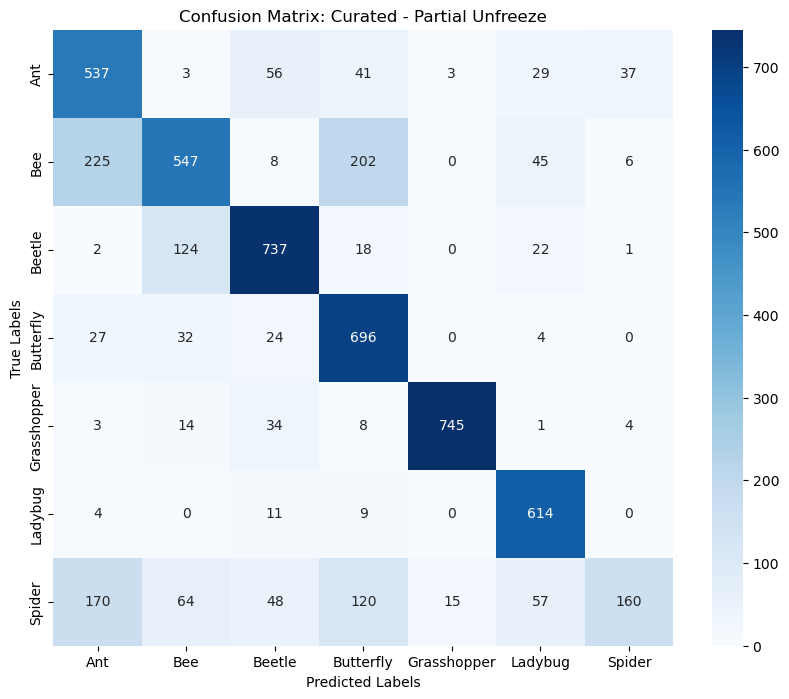

([{'acc': 0.9340425531914893,
   'f1': 0.933804536606489,
   'auc': 0.9951130839480007},
  {'acc': 0.9680851063829787,
   'f1': 0.9684336486246762,
   'auc': 0.9991957355678307},
  {'acc': 0.9402985074626866,
   'f1': 0.9400923868230794,
   'auc': 0.9969918954600381},
  {'acc': 0.9168443496801706,
   'f1': 0.9174626592417751,
   'auc': 0.9914022670051219},
  {'acc': 0.9573560767590619,
   'f1': 0.9565213775464052,
   'auc': 0.9972427371327809}],
 0.7328854185581987)

In [17]:
run_experiment("Curated - Partial Unfreeze", get_partial_unfreeze_model)


==================== Curated - LoRA ====================

--- Starting Fold 1 ---
Fold 1 Results -> Acc: 0.8319 | F1: 0.7858 | AUC: 0.9743

--- Starting Fold 2 ---
Fold 2 Results -> Acc: 0.8660 | F1: 0.8293 | AUC: 0.9887

--- Starting Fold 3 ---
Fold 3 Results -> Acc: 0.8657 | F1: 0.8295 | AUC: 0.9766

--- Starting Fold 4 ---
Fold 4 Results -> Acc: 0.8252 | F1: 0.7754 | AUC: 0.9744

--- Starting Fold 5 ---
Fold 5 Results -> Acc: 0.8316 | F1: 0.7887 | AUC: 0.9828

Evaluating final model on Kaggle Test Set...

########## SUMMARY: Curated - LoRA ##########
Avg CV Acc: 0.8441
Final Test Acc: 0.5012
Final Test F1:  0.4248
Final Test AUC: 0.8936
Total Time:     370.63s


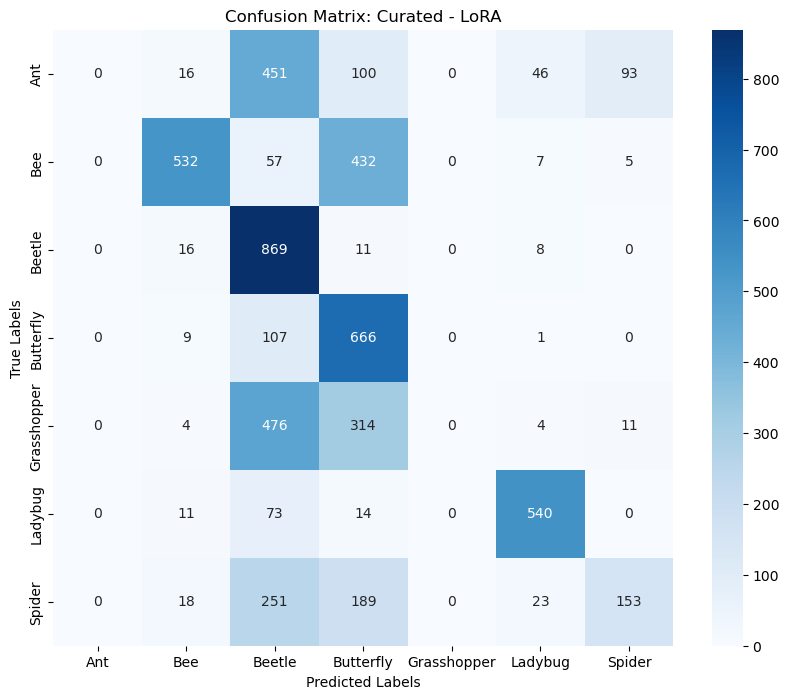

([{'acc': 0.8319148936170213,
   'f1': 0.7858039394334972,
   'auc': 0.9743314530656794},
  {'acc': 0.8659574468085106,
   'f1': 0.8293183982498605,
   'auc': 0.9886762285723931},
  {'acc': 0.8656716417910447,
   'f1': 0.8294906050452509,
   'auc': 0.9766099382414745},
  {'acc': 0.8251599147121536,
   'f1': 0.775394875135488,
   'auc': 0.9744383845222205},
  {'acc': 0.8315565031982942,
   'f1': 0.7886599448790743,
   'auc': 0.9827813341729962}],
 0.5011803159615036)

In [18]:
run_experiment("Curated - LoRA", get_competitive_lora_model)

#### Full iNat

In [19]:
train_val_dataset = InatPixelDataset(ds, all_valid_indices, iNat36_label_df, transform=preprocess)


==================== Full iNat - Partial Unfreeze ====================

--- Starting Fold 1 ---
Fold 1 Results -> Acc: 0.9318 | F1: 0.9308 | AUC: 0.9935

--- Starting Fold 2 ---
Fold 2 Results -> Acc: 0.9289 | F1: 0.9282 | AUC: 0.9940

--- Starting Fold 3 ---
Fold 3 Results -> Acc: 0.9251 | F1: 0.9261 | AUC: 0.9834

--- Starting Fold 4 ---
Fold 4 Results -> Acc: 0.9280 | F1: 0.9277 | AUC: 0.9914

--- Starting Fold 5 ---
Fold 5 Results -> Acc: 0.9223 | F1: 0.9234 | AUC: 0.9918

Evaluating final model on Kaggle Test Set...

########## SUMMARY: Full iNat - Partial Unfreeze ##########
Avg CV Acc: 0.9272
Final Test Acc: 0.7374
Final Test F1:  0.7282
Final Test AUC: 0.9641
Total Time:     695.64s


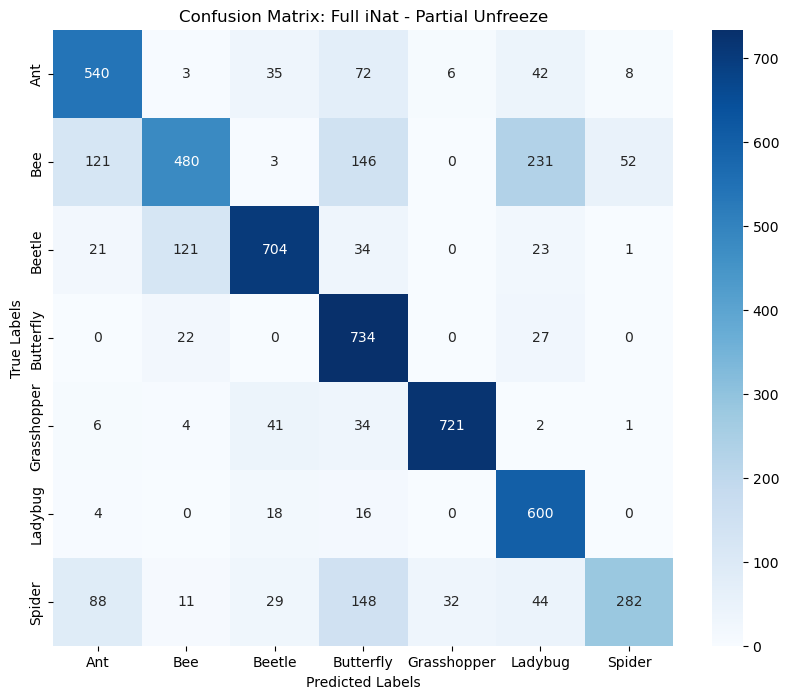

([{'acc': 0.9318181818181818,
   'f1': 0.9307683172604796,
   'auc': 0.993545207905718},
  {'acc': 0.9289099526066351,
   'f1': 0.9281875555250715,
   'auc': 0.9940011858412835},
  {'acc': 0.9251184834123223,
   'f1': 0.9261085331937411,
   'auc': 0.9834426228183766},
  {'acc': 0.9279620853080569,
   'f1': 0.9277474310877483,
   'auc': 0.9913896711987071},
  {'acc': 0.9222748815165877,
   'f1': 0.9233776000761428,
   'auc': 0.9918091503336862}],
 0.7374250953332123)

In [20]:
run_experiment("Full iNat - Partial Unfreeze", get_partial_unfreeze_model)


==================== Full iNat - LoRA ====================

--- Starting Fold 1 ---
Fold 1 Results -> Acc: 0.8930 | F1: 0.8714 | AUC: 0.9865

--- Starting Fold 2 ---
Fold 2 Results -> Acc: 0.8938 | F1: 0.8767 | AUC: 0.9852

--- Starting Fold 3 ---
Fold 3 Results -> Acc: 0.8853 | F1: 0.8664 | AUC: 0.9812

--- Starting Fold 4 ---
Fold 4 Results -> Acc: 0.8739 | F1: 0.8424 | AUC: 0.9781

--- Starting Fold 5 ---
Fold 5 Results -> Acc: 0.8626 | F1: 0.8257 | AUC: 0.9763

Evaluating final model on Kaggle Test Set...

########## SUMMARY: Full iNat - LoRA ##########
Avg CV Acc: 0.8817
Final Test Acc: 0.5357
Final Test F1:  0.4546
Final Test AUC: 0.9082
Total Time:     739.33s


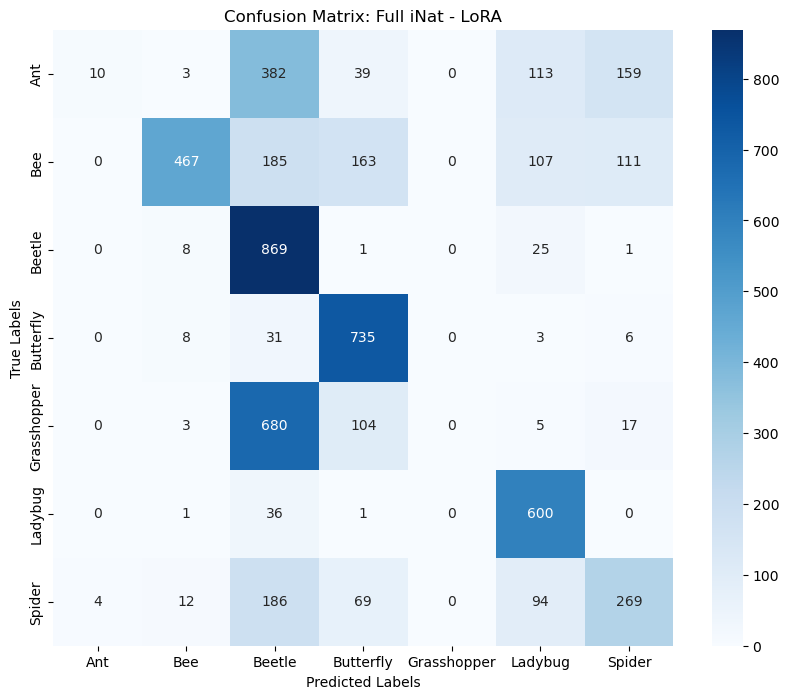

([{'acc': 0.8929924242424242,
   'f1': 0.8714035948603172,
   'auc': 0.986487554107094},
  {'acc': 0.8938388625592417,
   'f1': 0.8767392411187171,
   'auc': 0.9852281896748663},
  {'acc': 0.885308056872038,
   'f1': 0.8664117039767324,
   'auc': 0.9811766402499131},
  {'acc': 0.8739336492890996,
   'f1': 0.8423904302417158,
   'auc': 0.9780777764793933},
  {'acc': 0.8625592417061612,
   'f1': 0.8257250729688546,
   'auc': 0.9762636241498969}],
 0.5356818594516071)

In [21]:
run_experiment("Full iNat - LoRA", get_competitive_lora_model)

#### Random Sample


==================== Random Trial 1 ====================

--- Starting Fold 1 ---
Fold 1 Results -> Acc: 0.9213 | F1: 0.9188 | AUC: 0.9924

--- Starting Fold 2 ---
Fold 2 Results -> Acc: 0.9149 | F1: 0.9157 | AUC: 0.9864

--- Starting Fold 3 ---
Fold 3 Results -> Acc: 0.9104 | F1: 0.9095 | AUC: 0.9827

--- Starting Fold 4 ---
Fold 4 Results -> Acc: 0.9318 | F1: 0.9321 | AUC: 0.9940

--- Starting Fold 5 ---
Fold 5 Results -> Acc: 0.9147 | F1: 0.9145 | AUC: 0.9845

Evaluating final model on Kaggle Test Set...

########## SUMMARY: Random Trial 1 ##########
Avg CV Acc: 0.9186
Final Test Acc: 0.7788
Final Test F1:  0.7757
Final Test AUC: 0.9645
Total Time:     352.58s


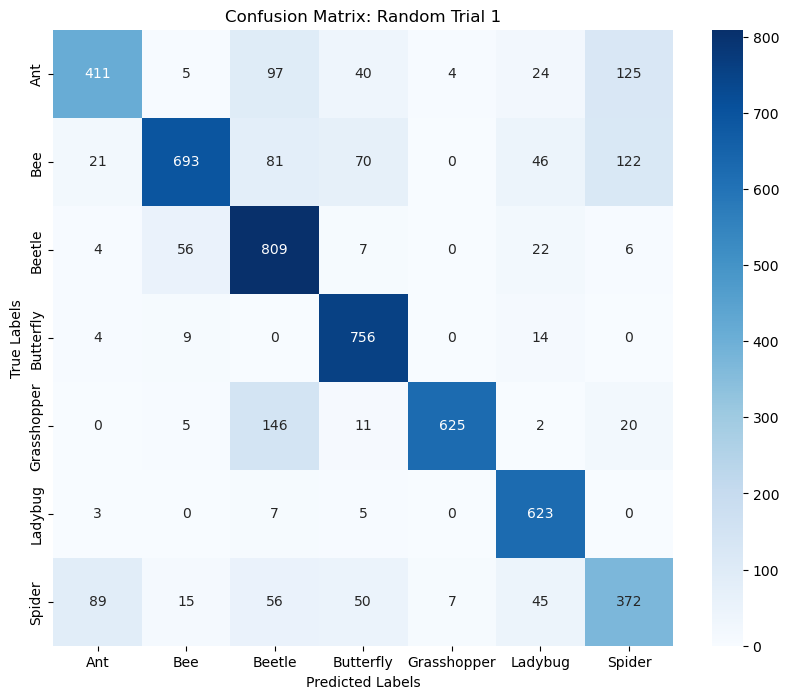


==================== Random Trial 2 ====================

--- Starting Fold 1 ---
Fold 1 Results -> Acc: 0.9255 | F1: 0.9230 | AUC: 0.9905

--- Starting Fold 2 ---
Fold 2 Results -> Acc: 0.9319 | F1: 0.9327 | AUC: 0.9942

--- Starting Fold 3 ---
Fold 3 Results -> Acc: 0.9339 | F1: 0.9326 | AUC: 0.9923

--- Starting Fold 4 ---
Fold 4 Results -> Acc: 0.9168 | F1: 0.9146 | AUC: 0.9928

--- Starting Fold 5 ---
Fold 5 Results -> Acc: 0.9190 | F1: 0.9183 | AUC: 0.9904

Evaluating final model on Kaggle Test Set...

########## SUMMARY: Random Trial 2 ##########
Avg CV Acc: 0.9254
Final Test Acc: 0.7687
Final Test F1:  0.7616
Final Test AUC: 0.9691
Total Time:     351.71s


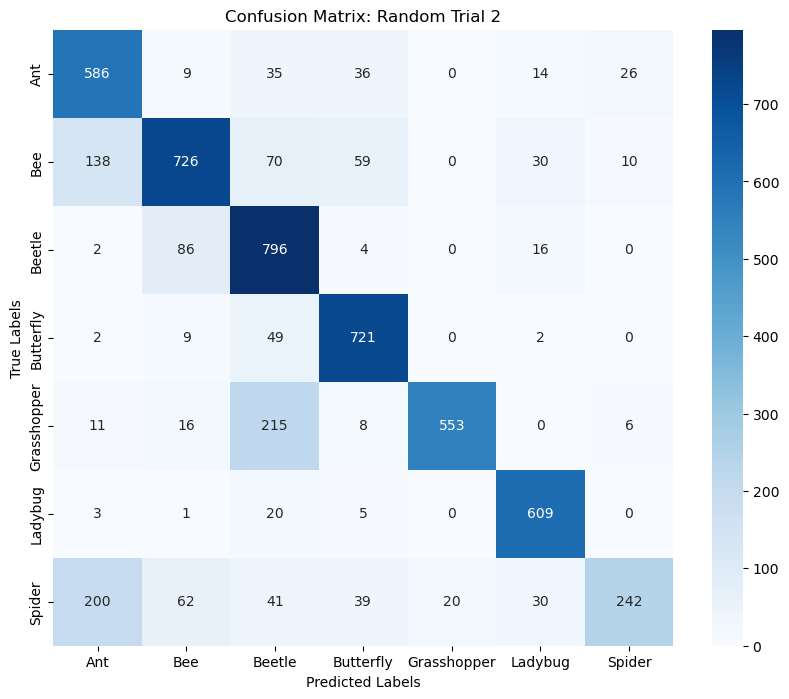


==================== Random Trial 3 ====================

--- Starting Fold 1 ---
Fold 1 Results -> Acc: 0.9085 | F1: 0.9086 | AUC: 0.9833

--- Starting Fold 2 ---
Fold 2 Results -> Acc: 0.9106 | F1: 0.9113 | AUC: 0.9857

--- Starting Fold 3 ---
Fold 3 Results -> Acc: 0.9254 | F1: 0.9200 | AUC: 0.9899

--- Starting Fold 4 ---
Fold 4 Results -> Acc: 0.9104 | F1: 0.9106 | AUC: 0.9913

--- Starting Fold 5 ---
Fold 5 Results -> Acc: 0.9147 | F1: 0.9131 | AUC: 0.9843

Evaluating final model on Kaggle Test Set...

########## SUMMARY: Random Trial 3 ##########
Avg CV Acc: 0.9139
Final Test Acc: 0.7834
Final Test F1:  0.7758
Final Test AUC: 0.9661
Total Time:     353.76s


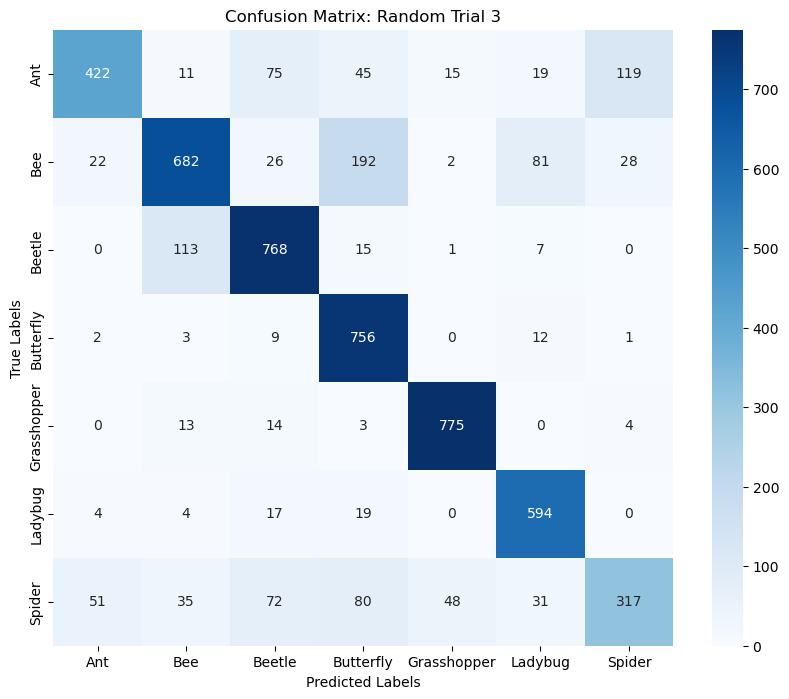


==================== Random Trial 4 ====================

--- Starting Fold 1 ---
Fold 1 Results -> Acc: 0.9064 | F1: 0.9073 | AUC: 0.9844

--- Starting Fold 2 ---
Fold 2 Results -> Acc: 0.9213 | F1: 0.9173 | AUC: 0.9917

--- Starting Fold 3 ---
Fold 3 Results -> Acc: 0.9211 | F1: 0.9198 | AUC: 0.9921

--- Starting Fold 4 ---
Fold 4 Results -> Acc: 0.9275 | F1: 0.9245 | AUC: 0.9864

--- Starting Fold 5 ---
Fold 5 Results -> Acc: 0.9296 | F1: 0.9283 | AUC: 0.9952

Evaluating final model on Kaggle Test Set...

########## SUMMARY: Random Trial 4 ##########
Avg CV Acc: 0.9212
Final Test Acc: 0.7331
Final Test F1:  0.7271
Final Test AUC: 0.9646
Total Time:     352.20s


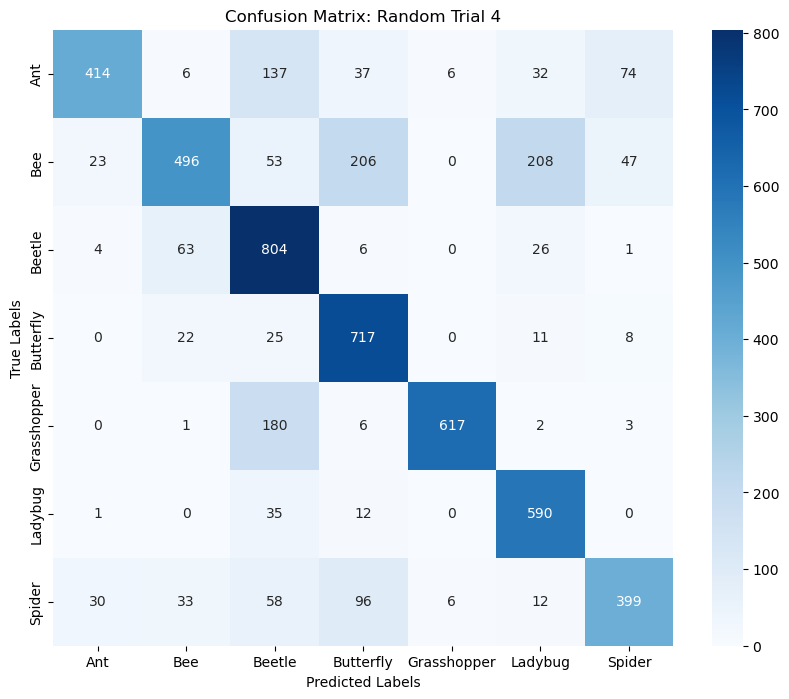


==================== Random Trial 5 ====================

--- Starting Fold 1 ---
Fold 1 Results -> Acc: 0.9000 | F1: 0.8996 | AUC: 0.9889

--- Starting Fold 2 ---
Fold 2 Results -> Acc: 0.9106 | F1: 0.9087 | AUC: 0.9839

--- Starting Fold 3 ---
Fold 3 Results -> Acc: 0.9211 | F1: 0.9219 | AUC: 0.9874

--- Starting Fold 4 ---
Fold 4 Results -> Acc: 0.9168 | F1: 0.9155 | AUC: 0.9849

--- Starting Fold 5 ---
Fold 5 Results -> Acc: 0.9147 | F1: 0.9182 | AUC: 0.9929

Evaluating final model on Kaggle Test Set...

########## SUMMARY: Random Trial 5 ##########
Avg CV Acc: 0.9127
Final Test Acc: 0.8061
Final Test F1:  0.7995
Final Test AUC: 0.9699
Total Time:     350.50s


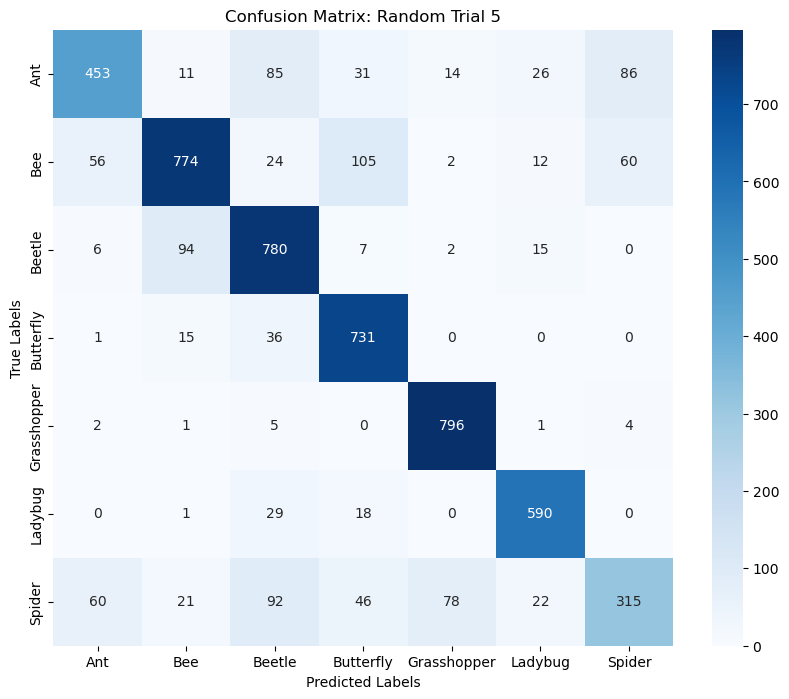


==================== Random Trial 6 ====================

--- Starting Fold 1 ---
Fold 1 Results -> Acc: 0.9170 | F1: 0.9134 | AUC: 0.9888

--- Starting Fold 2 ---
Fold 2 Results -> Acc: 0.9106 | F1: 0.9098 | AUC: 0.9919

--- Starting Fold 3 ---
Fold 3 Results -> Acc: 0.9275 | F1: 0.9278 | AUC: 0.9882

--- Starting Fold 4 ---
Fold 4 Results -> Acc: 0.9232 | F1: 0.9226 | AUC: 0.9910

--- Starting Fold 5 ---
Fold 5 Results -> Acc: 0.9360 | F1: 0.9351 | AUC: 0.9873

Evaluating final model on Kaggle Test Set...

########## SUMMARY: Random Trial 6 ##########
Avg CV Acc: 0.9229
Final Test Acc: 0.7721
Final Test F1:  0.7627
Final Test AUC: 0.9724
Total Time:     351.87s


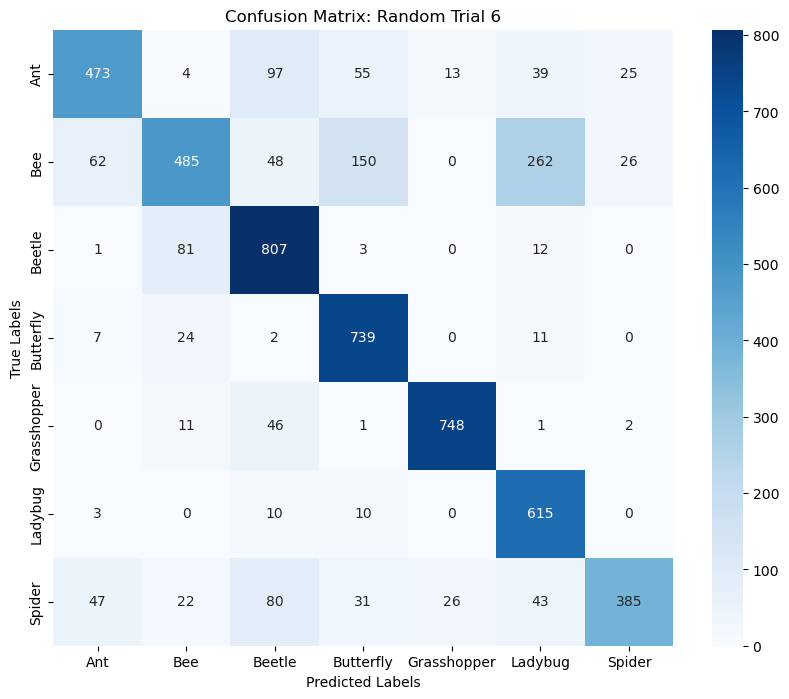


==================== Random Trial 7 ====================

--- Starting Fold 1 ---
Fold 1 Results -> Acc: 0.9043 | F1: 0.9028 | AUC: 0.9839

--- Starting Fold 2 ---
Fold 2 Results -> Acc: 0.9191 | F1: 0.9167 | AUC: 0.9881

--- Starting Fold 3 ---
Fold 3 Results -> Acc: 0.9403 | F1: 0.9404 | AUC: 0.9882

--- Starting Fold 4 ---
Fold 4 Results -> Acc: 0.9382 | F1: 0.9362 | AUC: 0.9929

--- Starting Fold 5 ---
Fold 5 Results -> Acc: 0.9232 | F1: 0.9249 | AUC: 0.9954

Evaluating final model on Kaggle Test Set...

########## SUMMARY: Random Trial 7 ##########
Avg CV Acc: 0.9250
Final Test Acc: 0.7322
Final Test F1:  0.7166
Final Test AUC: 0.9576
Total Time:     353.55s


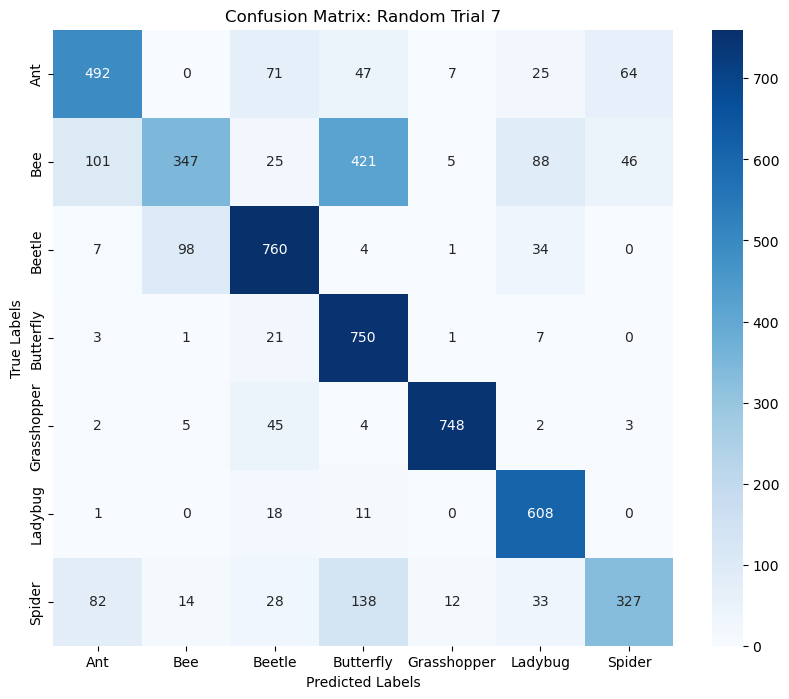


==================== Random Trial 8 ====================

--- Starting Fold 1 ---
Fold 1 Results -> Acc: 0.9043 | F1: 0.9077 | AUC: 0.9923

--- Starting Fold 2 ---
Fold 2 Results -> Acc: 0.9255 | F1: 0.9254 | AUC: 0.9883

--- Starting Fold 3 ---
Fold 3 Results -> Acc: 0.9275 | F1: 0.9279 | AUC: 0.9891

--- Starting Fold 4 ---
Fold 4 Results -> Acc: 0.9510 | F1: 0.9502 | AUC: 0.9932

--- Starting Fold 5 ---
Fold 5 Results -> Acc: 0.9275 | F1: 0.9266 | AUC: 0.9899

Evaluating final model on Kaggle Test Set...

########## SUMMARY: Random Trial 8 ##########
Avg CV Acc: 0.9272
Final Test Acc: 0.7645
Final Test F1:  0.7554
Final Test AUC: 0.9698
Total Time:     352.88s


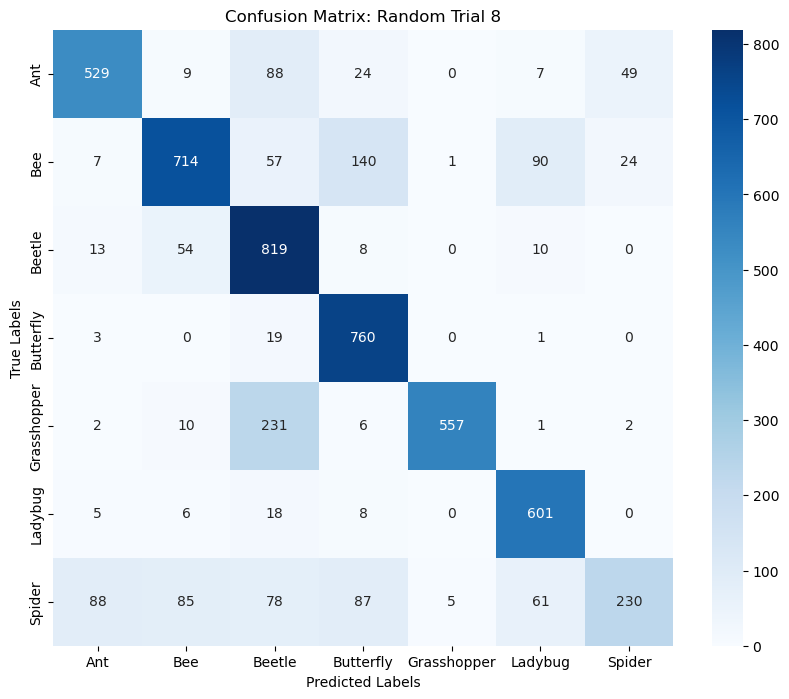


==================== Random Trial 9 ====================

--- Starting Fold 1 ---
Fold 1 Results -> Acc: 0.9234 | F1: 0.9244 | AUC: 0.9876

--- Starting Fold 2 ---
Fold 2 Results -> Acc: 0.9319 | F1: 0.9328 | AUC: 0.9931

--- Starting Fold 3 ---
Fold 3 Results -> Acc: 0.9211 | F1: 0.9197 | AUC: 0.9823

--- Starting Fold 4 ---
Fold 4 Results -> Acc: 0.9147 | F1: 0.9135 | AUC: 0.9899

--- Starting Fold 5 ---
Fold 5 Results -> Acc: 0.9275 | F1: 0.9245 | AUC: 0.9895

Evaluating final model on Kaggle Test Set...

########## SUMMARY: Random Trial 9 ##########
Avg CV Acc: 0.9237
Final Test Acc: 0.7510
Final Test F1:  0.7418
Final Test AUC: 0.9640
Total Time:     351.02s


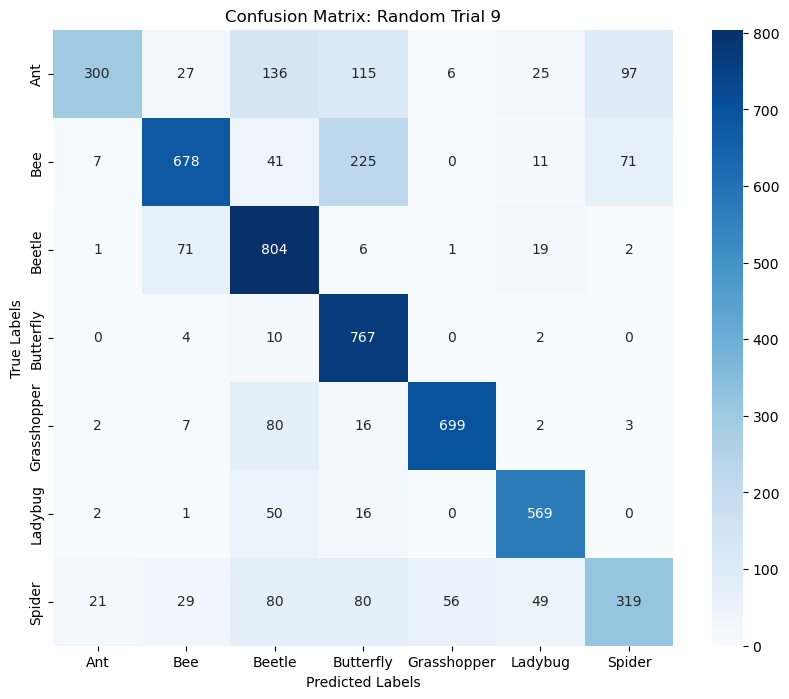


==================== Random Trial 10 ====================

--- Starting Fold 1 ---
Fold 1 Results -> Acc: 0.9191 | F1: 0.9184 | AUC: 0.9914

--- Starting Fold 2 ---
Fold 2 Results -> Acc: 0.9277 | F1: 0.9278 | AUC: 0.9928

--- Starting Fold 3 ---
Fold 3 Results -> Acc: 0.9275 | F1: 0.9273 | AUC: 0.9947

--- Starting Fold 4 ---
Fold 4 Results -> Acc: 0.9041 | F1: 0.8979 | AUC: 0.9826

--- Starting Fold 5 ---
Fold 5 Results -> Acc: 0.9296 | F1: 0.9304 | AUC: 0.9937

Evaluating final model on Kaggle Test Set...

########## SUMMARY: Random Trial 10 ##########
Avg CV Acc: 0.9216
Final Test Acc: 0.7912
Final Test F1:  0.7877
Final Test AUC: 0.9735
Total Time:     350.22s


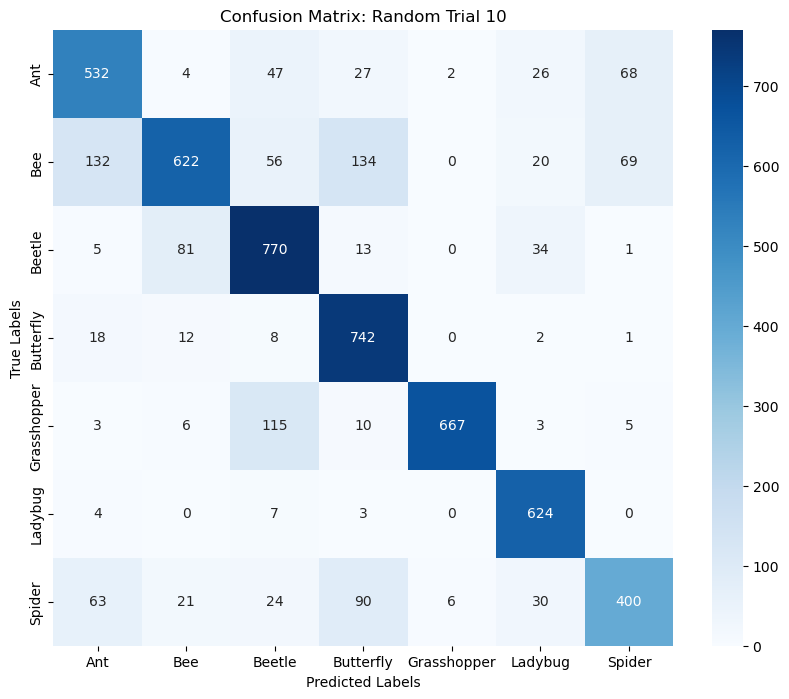

ValueError: setting an array element with a sequence. The requested array has an inhomogeneous shape after 2 dimensions. The detected shape was (10, 2) + inhomogeneous part.

In [22]:
target_size = 2347 # size matching original curated set
random_results = []
for trial in range(1, 11):
    np.random.seed(42 + trial)
    random_indices = np.random.choice(all_valid_indices, size=target_size, replace=False).tolist()
    train_val_dataset = InatPixelDataset(ds, random_indices, iNat36_label_df, transform=preprocess)
    random_results.append(run_experiment(f"Random Trial {trial}", get_partial_unfreeze_model))
    torch.cuda.empty_cache()

print(f"\nRandom Mean: {np.mean(random_results):.4f} (+/- {np.std(random_results):.4f})")

In [23]:
random_results

[([{'acc': 0.9212765957446809,
    'f1': 0.9187928634722916,
    'auc': 0.9923781148445684},
   {'acc': 0.9148936170212766,
    'f1': 0.915681881661786,
    'auc': 0.9864017238796244},
   {'acc': 0.9104477611940298,
    'f1': 0.9095216572033583,
    'auc': 0.9826879540028789},
   {'acc': 0.9317697228144989,
    'f1': 0.9320615872817399,
    'auc': 0.9939986265159798},
   {'acc': 0.9147121535181236,
    'f1': 0.9144516530875477,
    'auc': 0.9844754613197871}],
  0.7788269475213365),
 ([{'acc': 0.925531914893617,
    'f1': 0.9230024898224387,
    'auc': 0.9905063881304458},
   {'acc': 0.9319148936170213,
    'f1': 0.9327091007958935,
    'auc': 0.9942457864226945},
   {'acc': 0.9339019189765458,
    'f1': 0.9325622554811215,
    'auc': 0.9923126595127105},
   {'acc': 0.9168443496801706,
    'f1': 0.914571279861303,
    'auc': 0.9928368911346038},
   {'acc': 0.9189765458422174,
    'f1': 0.9182518702039381,
    'auc': 0.990410658574652}],
  0.768658071545306),
 ([{'acc': 0.90851063829787

In [27]:
random_results = [([{'acc': 0.9212765957446809,
    'f1': 0.9187928634722916,
    'auc': 0.9923781148445684},
   {'acc': 0.9148936170212766,
    'f1': 0.915681881661786,
    'auc': 0.9864017238796244},
   {'acc': 0.9104477611940298,
    'f1': 0.9095216572033583,
    'auc': 0.9826879540028789},
   {'acc': 0.9317697228144989,
    'f1': 0.9320615872817399,
    'auc': 0.9939986265159798},
   {'acc': 0.9147121535181236,
    'f1': 0.9144516530875477,
    'auc': 0.9844754613197871}],
  0.7788269475213365),
 ([{'acc': 0.925531914893617,
    'f1': 0.9230024898224387,
    'auc': 0.9905063881304458},
   {'acc': 0.9319148936170213,
    'f1': 0.9327091007958935,
    'auc': 0.9942457864226945},
   {'acc': 0.9339019189765458,
    'f1': 0.9325622554811215,
    'auc': 0.9923126595127105},
   {'acc': 0.9168443496801706,
    'f1': 0.914571279861303,
    'auc': 0.9928368911346038},
   {'acc': 0.9189765458422174,
    'f1': 0.9182518702039381,
    'auc': 0.990410658574652}],
  0.768658071545306),
 ([{'acc': 0.9085106382978724,
    'f1': 0.9086299898347772,
    'auc': 0.9832870648656022},
   {'acc': 0.9106382978723404,
    'f1': 0.9112632189572573,
    'auc': 0.9856998408409824},
   {'acc': 0.9253731343283582,
    'f1': 0.9200335715400791,
    'auc': 0.9899443623819442},
   {'acc': 0.9104477611940298,
    'f1': 0.9105931109063823,
    'auc': 0.9912728090025674},
   {'acc': 0.9147121535181236,
    'f1': 0.9131260516509756,
    'auc': 0.9842797250414093}],
  0.7833666242963501),
 ([{'acc': 0.9063829787234042,
    'f1': 0.9073098469175417,
    'auc': 0.9843717341293304},
   {'acc': 0.9212765957446809,
    'f1': 0.9173194804304888,
    'auc': 0.991697776924726},
   {'acc': 0.9211087420042644,
    'f1': 0.9198395826307099,
    'auc': 0.9921055684213272},
   {'acc': 0.9275053304904051,
    'f1': 0.9244718040246471,
    'auc': 0.986402133906196},
   {'acc': 0.929637526652452,
    'f1': 0.9283349519434603,
    'auc': 0.9952078649701274}],
  0.7330670056291992),
 ([{'acc': 0.9, 'f1': 0.8995515348391889, 'auc': 0.9888747015229468},
   {'acc': 0.9106382978723404,
    'f1': 0.9086652746419964,
    'auc': 0.9839329120532077},
   {'acc': 0.9211087420042644,
    'f1': 0.9218800695133798,
    'auc': 0.9873935658732816},
   {'acc': 0.9168443496801706,
    'f1': 0.9154924778894409,
    'auc': 0.9849492179683875},
   {'acc': 0.9147121535181236,
    'f1': 0.9181535650564152,
    'auc': 0.9928598732605147}],
  0.8060650081714182),
 ([{'acc': 0.9170212765957447,
    'f1': 0.9133710324724699,
    'auc': 0.9887994676054773},
   {'acc': 0.9106382978723404,
    'f1': 0.9097730984765966,
    'auc': 0.991882609919829},
   {'acc': 0.9275053304904051,
    'f1': 0.9277903470961955,
    'auc': 0.9881558909342137},
   {'acc': 0.9232409381663113,
    'f1': 0.922574779494513,
    'auc': 0.9909886034327571},
   {'acc': 0.9360341151385928,
    'f1': 0.9350559083469714,
    'auc': 0.9873291571462329}],
  0.7721082258943164),
 ([{'acc': 0.9042553191489362,
    'f1': 0.9028082092021514,
    'auc': 0.983927934424365},
   {'acc': 0.9191489361702128,
    'f1': 0.9167102137961197,
    'auc': 0.9881423330372885},
   {'acc': 0.9402985074626866,
    'f1': 0.9403716804671605,
    'auc': 0.9882381243363711},
   {'acc': 0.9381663113006397,
    'f1': 0.9362017690736137,
    'auc': 0.9929086073559487},
   {'acc': 0.9232409381663113,
    'f1': 0.9248884284738171,
    'auc': 0.9953836409105096}],
  0.7321590702741965),
 ([{'acc': 0.9042553191489362,
    'f1': 0.9077053553798611,
    'auc': 0.9922975442549937},
   {'acc': 0.925531914893617,
    'f1': 0.9254253228228173,
    'auc': 0.9882850392322293},
   {'acc': 0.9275053304904051,
    'f1': 0.9278977147177675,
    'auc': 0.98911502423893},
   {'acc': 0.9509594882729211,
    'f1': 0.9502342353210479,
    'auc': 0.9932068666905177},
   {'acc': 0.9275053304904051,
    'f1': 0.9266000441211126,
    'auc': 0.9898981312407159}],
  0.7644815689122935),
 ([{'acc': 0.9234042553191489,
    'f1': 0.9244362409476342,
    'auc': 0.987609565211751},
   {'acc': 0.9319148936170213,
    'f1': 0.93278291736696,
    'auc': 0.9931322642444609},
   {'acc': 0.9211087420042644,
    'f1': 0.9196833461998533,
    'auc': 0.9822556929742874},
   {'acc': 0.9147121535181236,
    'f1': 0.9134673835666672,
    'auc': 0.9899163839911614},
   {'acc': 0.9275053304904051,
    'f1': 0.9244710731711462,
    'auc': 0.9895241607658958}],
  0.7510441256582532),
 ([{'acc': 0.9191489361702128,
    'f1': 0.9183874763383275,
    'auc': 0.9914169742266258},
   {'acc': 0.9276595744680851,
    'f1': 0.9278013072767293,
    'auc': 0.9927853678754152},
   {'acc': 0.9275053304904051,
    'f1': 0.9272984062604065,
    'auc': 0.9946624399419524},
   {'acc': 0.9040511727078892,
    'f1': 0.8979484310837286,
    'auc': 0.9826006902142924},
   {'acc': 0.929637526652452,
    'f1': 0.930395638424512,
    'auc': 0.9936894726250994}],
  0.7911748683493736)]

In [28]:
data = random_results

all_trial_test_accs = []
all_cv_accs = []
all_cv_f1s = []
all_cv_aucs = []

for cv_folds, test_acc in data:
    # collect final test accuracy per trial
    all_trial_test_accs.append(test_acc)
    
    # collect individual fold metrics
    for fold in cv_folds:
        all_cv_accs.append(fold['acc'])
        all_cv_f1s.append(fold['f1'])
        all_cv_aucs.append(fold['auc'])

print(f"{'='*30}")
print(f"RANDOM BASELINE FINAL SUMMARY")
print(f"{'='*30}")
print(f"Mean Final Test Acc (10 trials): {np.mean(all_trial_test_accs):.4f}")
print(f"Std Final Test Acc (10 trials):  {np.std(all_trial_test_accs):.4f}")
print(f"\nAverage CV Accuracy:  {np.mean(all_cv_accs):.4f}")
print(f"Average CV F1-Score:  {np.mean(all_cv_f1s):.4f}")
print(f"Average CV AUC:       {np.mean(all_cv_aucs):.4f}")
print(f"{'='*30}")

RANDOM BASELINE FINAL SUMMARY
Mean Final Test Acc (10 trials): 0.7681
Std Final Test Acc (10 trials):  0.0227

Average CV Accuracy:  0.9212
Average CV F1-Score:  0.9204
Average CV AUC:       0.9894


#### Curated Noise

#### Full Noise

#### Baseline (no training)

In [24]:
def get_baseline_model(num_classes):
    model = models.resnet50(weights="IMAGENET1K_V1")
    model.fc = nn.Linear(model.fc.in_features, num_classes)
    return model

def evaluate_baseline(model, test_loader, class_names):
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model.to(device)
    model.eval()
    
    test_preds, test_probs, test_targets = [], [], []
    start_time = time.time()
    
    print("Starting baseline evaluation on test set...")
    with torch.no_grad():
        for imgs, labels in test_loader:
            imgs = imgs.to(device)
            outputs = model(imgs)
            
            # collect probabilities for AUC and predictions for accuracy/F1
            probs = torch.softmax(outputs, dim=1)
            preds = torch.argmax(outputs, dim=1)
            
            test_probs.extend(probs.cpu().numpy())
            test_preds.extend(preds.cpu().numpy())
            test_targets.extend(labels.numpy())
            
    total_time = time.time() - start_time
    
    # calculate metrics
    acc = accuracy_score(test_targets, test_preds)
    f1 = f1_score(test_targets, test_preds, average='weighted')
    auc = roc_auc_score(test_targets, test_probs, multi_class='ovr')
    
    print(f"\n--- UN-FINETUNED BASELINE METRICS ---")
    print(f"Accuracy:  {acc:.4f}")
    print(f"F1-Score:  {f1:.4f}")
    print(f"AUC:       {auc:.4f}")
    print(f"Total Inference Time: {total_time:.2f} seconds")
    
    # generate confusion matrix
    cm = confusion_matrix(test_targets, test_preds)
    plt.figure(figsize=(10, 8))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Reds', 
                xticklabels=class_names, yticklabels=class_names)
    plt.title('Confusion Matrix: Un-finetuned ResNet-50 Baseline')
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.show()

Starting baseline evaluation on test set...

--- UN-FINETUNED BASELINE METRICS ---
Accuracy:  0.0656
F1-Score:  0.0671
AUC:       0.4534
Total Inference Time: 71.34 seconds


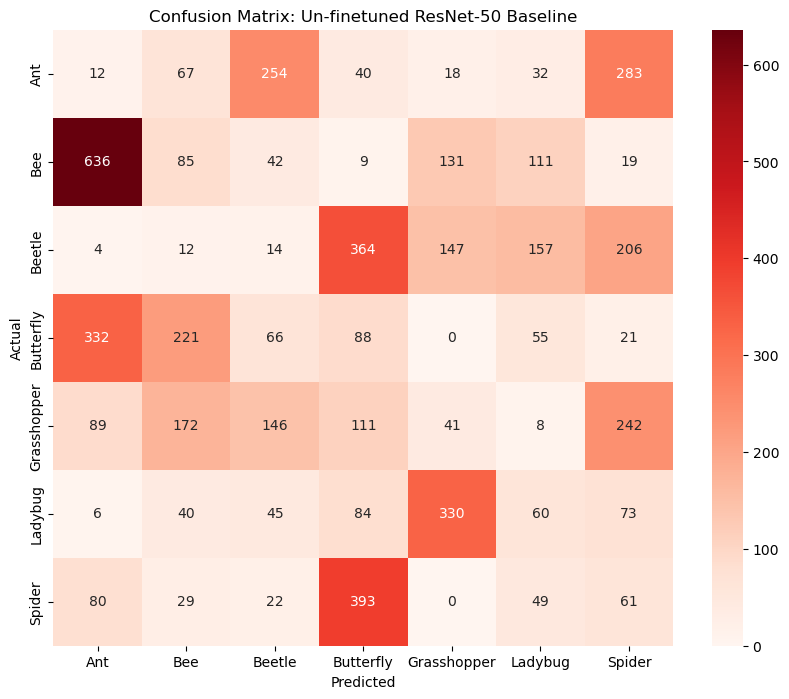

In [25]:
baseline_model = get_baseline_model(num_classes=7)
evaluate_baseline(baseline_model, test_loader, class_dirs)